<a href="https://colab.research.google.com/github/nonohuang0819/kaggle/blob/main/task3/task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# from google.colab import drive
# drive.mount("/content/drive")

import pandas as pd
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import SVC
import category_encoders as ce


In [2]:
filepath = "../Train/task3/introml_2024_task32_train.csv"
df = pd.read_csv(filepath)

In [31]:
# 前處理
cols = ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'class'] # 0/1變數, class 分類

for c in cols:
    df[c] = df[c].apply(lambda x: x if x=='?' else int(x[-1]))

df.replace("?", np.nan, inplace=True)

/var/folders/z8/tkcn56l93cb258d6cngvzl1h0000gn/T/ipykernel_24253/4238128312.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace("?", np.nan, inplace=True)


In [32]:
print(df.columns)

f8 = df.loc[:,'f8'] == np.nan
df[f8]

# df[df.loc[:,'f8'].isnull().any(axis=1)]
df[df.isnull().any(axis=1)]
df.isnull().sum()
df.dropna()

Index(['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10',
       'f11', 'f12', 'f13', 'f14', 'f15', 'class'],
      dtype='object')


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,class
0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.5812,2.2748,10.7618,0.1328,0.707,0.7827,1.0644,0.2197,0
1,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.8923,1.1706,2.0248,0.4691,0.5685,1.6567,0.7632,0.5765,0
2,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.1836,0.5778,2.9611,0.7307,0.9065,0.6243,0.7995,7.8733,0
3,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.2957,0.7494,3.4072,0.4306,0.2528,0.4312,0.7853,4.5719,0
4,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.9519,1.3822,4.0772,1.3046,0.5435,1.6834,0.9049,1.9258,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4791,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.6482,0.8203,4.0695,0.2277,1.0551,1.0765,0.4434,2.2287,5
4793,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.3654,1.0973,0.259,0.1595,0.0893,0.187,0.3522,0.5147,5
4795,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0265,1.2058,1.5087,0.1448,0.4024,2.435,0.7447,4.9996,5
4796,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.2645,0.2464,0.1314,0.4813,0.5992,0.1151,0.2646,2.3852,5


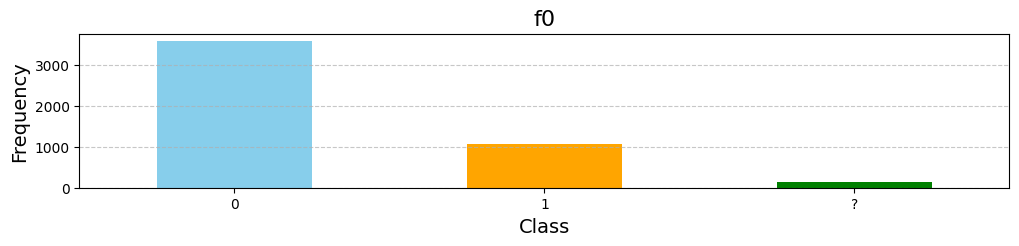

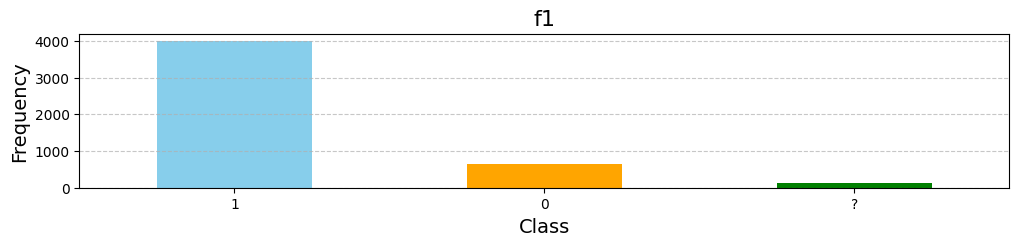

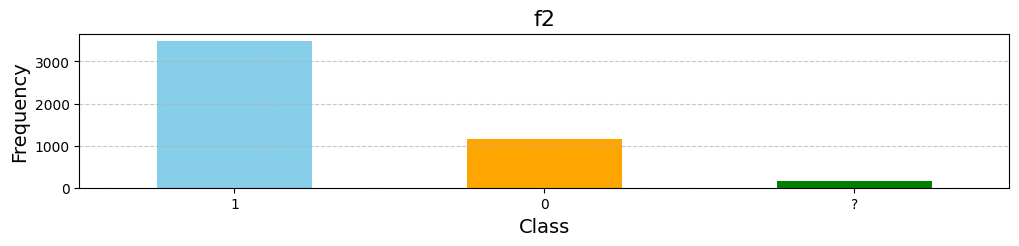

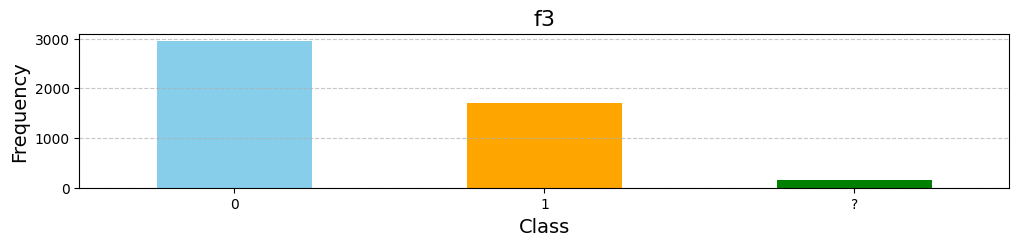

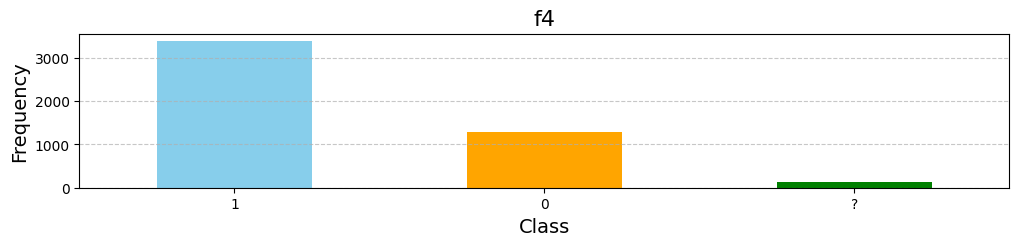

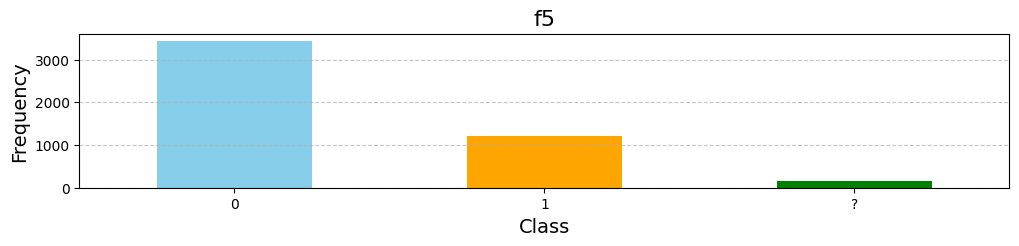

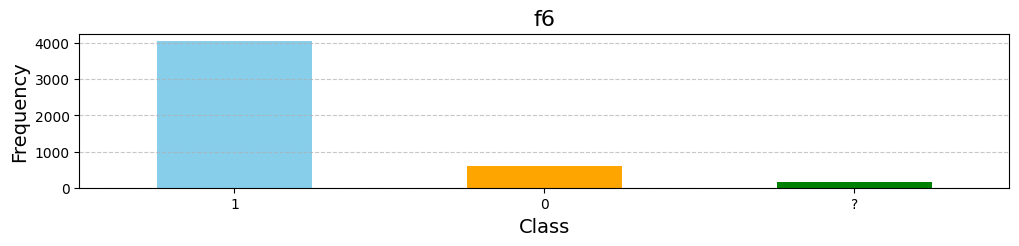

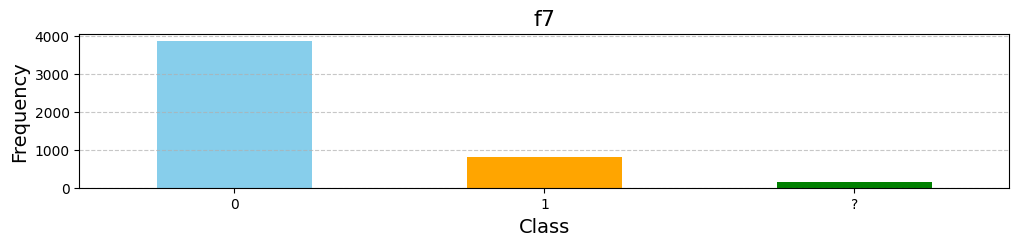

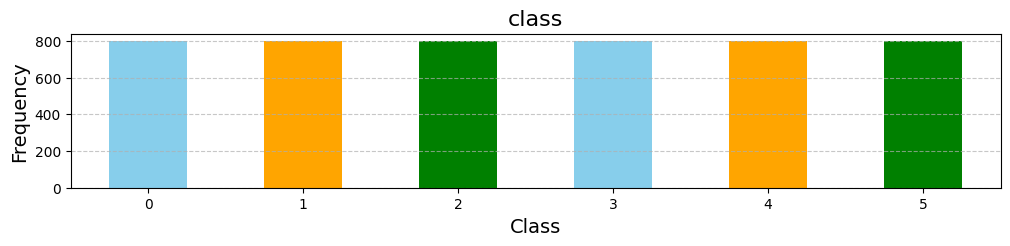

In [6]:
cols = ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'class']
for col in cols:
  plt.figure(figsize=(12, 2))  # 設定圖表大小
  value_counts=df[col].value_counts()
  value_counts.plot(kind='bar', color=['skyblue', 'orange', 'green'])
  # 添加標題和標籤
  plt.title(f'{col}', fontsize=16)
  plt.xlabel('Class', fontsize=14)
  plt.ylabel('Frequency', fontsize=14)
  plt.xticks(rotation=0)  # 保持類別標籤水平
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  # 顯示圖表
  plt.show()



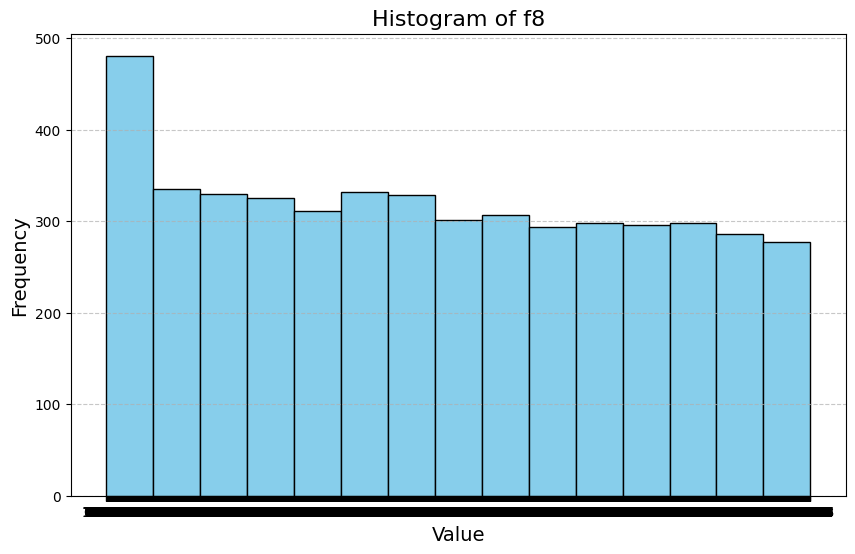

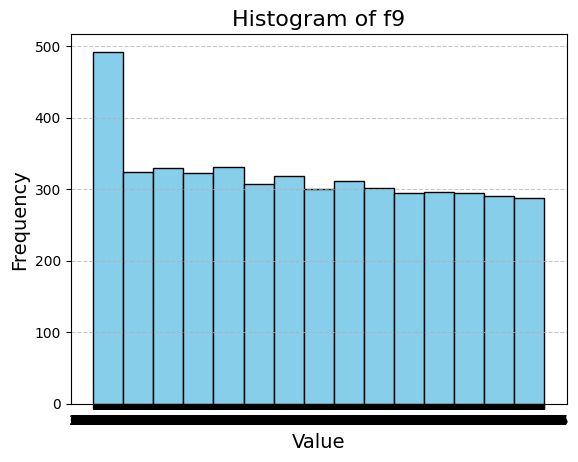

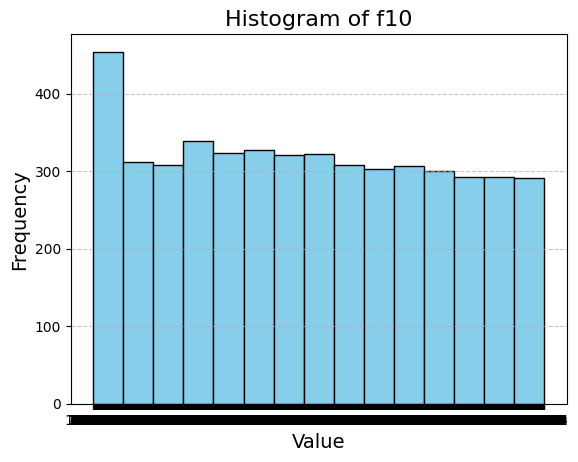

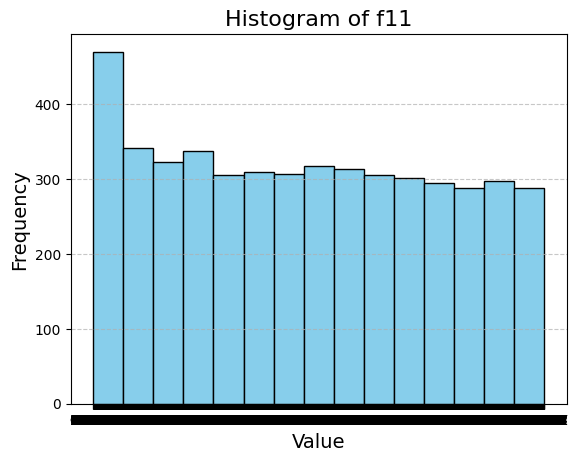

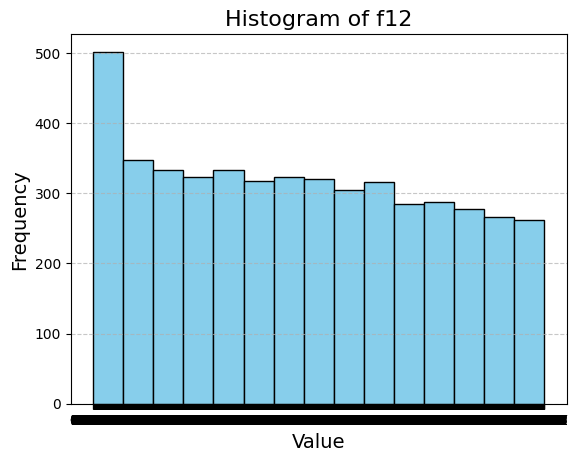

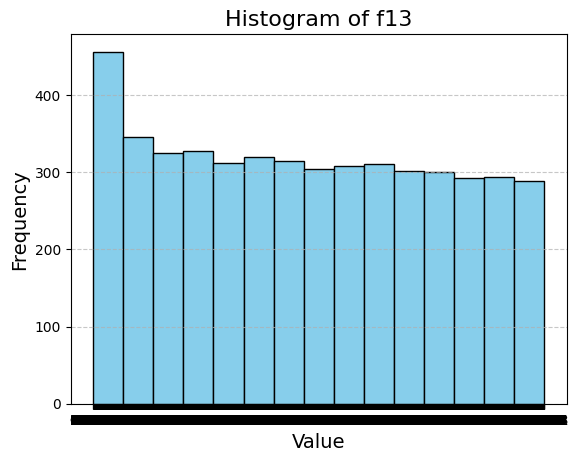

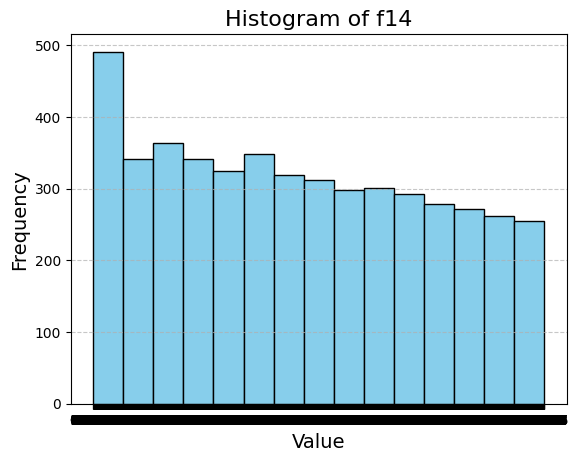

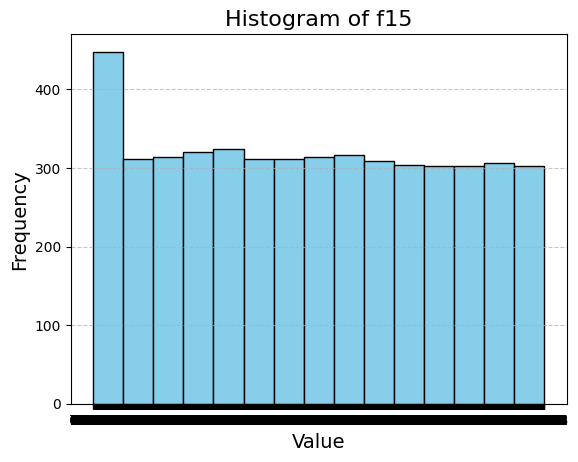

In [17]:
cols = ['f8', 'f9', 'f10','f11', 'f12', 'f13', 'f14', 'f15']

plt.figure(figsize=(10, 6))  # 設置畫布大小

for col in cols:
    plt.hist(df[col], bins=15, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}', fontsize=16)
    plt.xlabel('Value', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

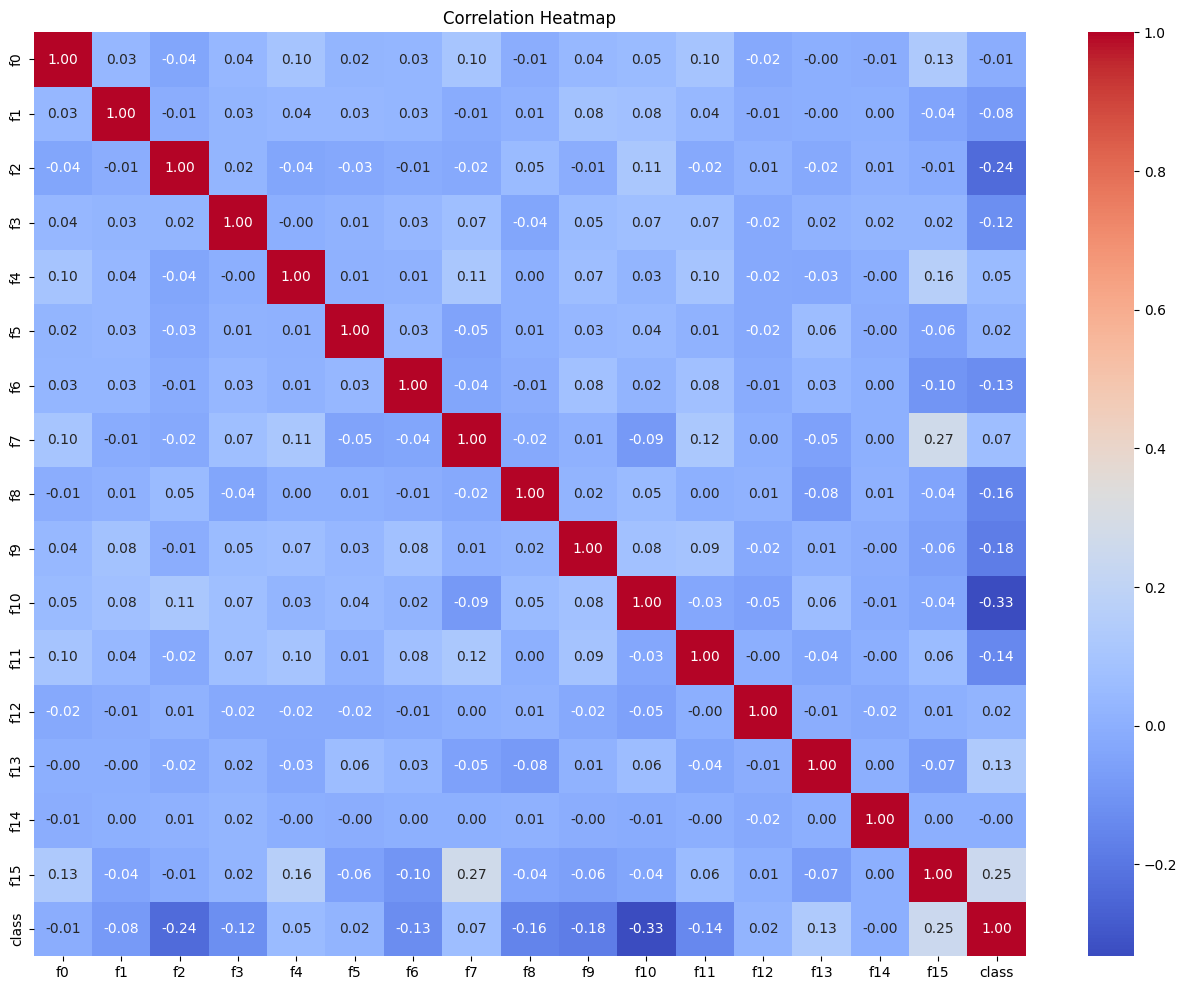

In [36]:
# 计算相关性矩阵
correlation_matrix = df.corr()
plt.figure(figsize=(16, 12))
# 创建热图
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [109]:
df['f15']

0       0.2197
1       0.5765
2       7.8733
3       4.5719
4       1.9258
         ...  
4795    4.9996
4796    2.3852
4797    6.1273
4798    4.1618
4799    4.5135
Name: f15, Length: 4800, dtype: object

In [34]:
from sklearn.impute import KNNImputer
col1 = ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7']
col2 = ['f8', 'f9', 'f10','f11', 'f12', 'f13', 'f14', 'f15']
imputer = KNNImputer(n_neighbors=5)
df_imputed_col2 = imputer.fit_transform(df[col2])
df_imputed_col2

df_imputed_col1 = imputer.fit_transform(df[col1])
df_imputed_col1.round()
df_imputed1 = pd.DataFrame(df_imputed_col1.round(), columns=col1)

# 眾數 .779
# df_imputed_col1 = df[col1]
# for class_ in range(6):
#     for c in col1:
#         most_frequent_value = df_imputed_col1[c].mode()[0]
#         df_imputed_col1[c].fillna(most_frequent_value, inplace=True)
# df_imputed1 = df_imputed_col1


df_imputed2 = pd.DataFrame(df_imputed_col2, columns=col2)

df2=pd.concat([df_imputed1, df_imputed2, df.iloc[:,-1]], axis=1)
df2.dropna()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,class
0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.5812,2.2748,10.7618,0.1328,0.7070,0.7827,1.0644,0.2197,0
1,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.8923,1.1706,2.0248,0.4691,0.5685,1.6567,0.7632,0.5765,0
2,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.1836,0.5778,2.9611,0.7307,0.9065,0.6243,0.7995,7.8733,0
3,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.2957,0.7494,3.4072,0.4306,0.2528,0.4312,0.7853,4.5719,0
4,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.9519,1.3822,4.0772,1.3046,0.5435,1.6834,0.9049,1.9258,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4795,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0265,1.2058,1.5087,0.1448,0.4024,2.4350,0.7447,4.9996,5
4796,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.2645,0.2464,0.1314,0.4813,0.5992,0.1151,0.2646,2.3852,5
4797,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.4825,1.2393,3.3957,0.1721,0.3529,2.3861,0.1033,6.1273,5
4798,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.3278,0.8246,4.8168,0.7692,0.0987,1.8784,0.0400,4.1618,5


In [29]:
from sklearn.feature_selection import SelectKBest, f_classif

# 全部 drop 掉
df_dropna = df2.dropna()

# conbine f7, f15 -> f16

df_dropna.insert(0, 'f16', df_dropna['f4'] * df_dropna['f15'])
df_dropna.insert(0, 'f17', df_dropna['f7'] * df_dropna['f15'])


# df_dropna = df_dropna.drop(['f14'], axis=1)


X = df_dropna.iloc[:, :-1]
y = df_dropna.iloc[:, -1] 

selector = SelectKBest(score_func=f_classif, k=15)
X_selected = selector.fit_transform(X, y)
print(selector.get_support(indices=True))


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


# # 5. 模型预测
y_pred = model.predict(X_test)

# print(y_pred)

# # 6. 性能评估
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

print(model.feature_importances_)

[ 0  1  2  3  4  5  6  8  9 10 11 12 13 15 17]
Accuracy: 0.7791666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.84      0.87       141
           1       0.73      0.86      0.79       183
           2       0.66      0.68      0.67       149
           3       0.69      0.75      0.72       167
           4       0.93      0.74      0.82       153
           5       0.84      0.79      0.81       167

    accuracy                           0.78       960
   macro avg       0.79      0.78      0.78       960
weighted avg       0.79      0.78      0.78       960

[0.02590063 0.10760535 0.01265858 0.00852447 0.02234297 0.01705223
 0.01923045 0.01080701 0.00927255 0.0083119  0.0659708  0.07740386
 0.19494556 0.08828702 0.04363037 0.08059291 0.0457248  0.16173855]


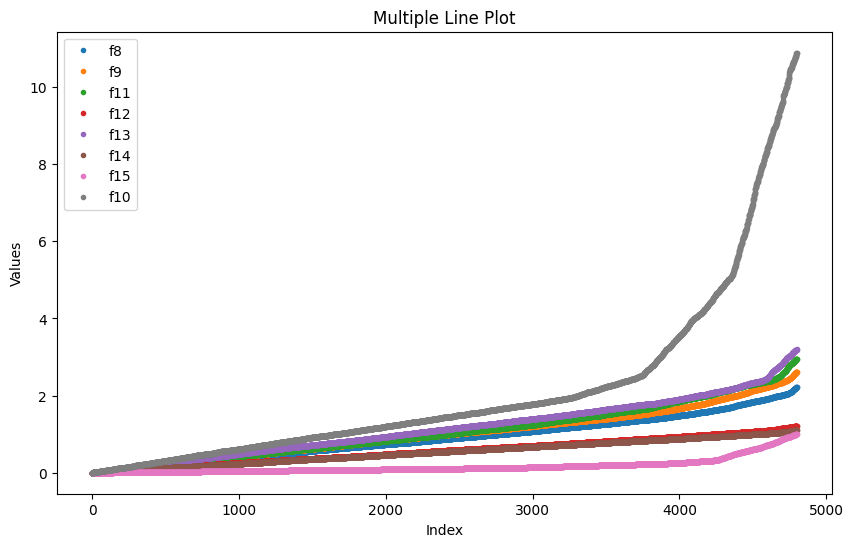

            f0       f1       f2       f3       f4       f5       f6       f7
class                                                                        
0      0.33625  0.95875  0.91375  0.48625  0.83250  0.33250  0.93375  0.13375
1      0.03000  0.76375  0.94250  0.24250  0.45375  0.11750  0.81625  0.05000
2      0.26625  0.89125  0.70125  0.60375  0.68125  0.24875  0.98500  0.25000
3      0.23250  0.93250  0.56000  0.22375  0.90250  0.34250  0.95500  0.09625
4      0.35625  0.80000  0.73875  0.32625  0.93625  0.16500  0.76375  0.44625
5      0.14000  0.81875  0.65625  0.27750  0.58375  0.31625  0.80000  0.02625


In [118]:
# 指定需要繪製的列
col2 = ['f8', 'f9', 'f11', 'f12', 'f13', 'f14', 'f15', 'f10']
# 設定圖形大小
plt.figure(figsize=(10, 6))

# 循環遍歷每一列，並繪製每條線
for col in col2:
    plt.plot(df2.loc[:, col].sort_values().reset_index(drop=True), '.', label=col)  # 用 'dot' 標記

# 添加圖例
plt.legend()

# 添加標籤
plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Multiple Line Plot')

# 顯示圖形
plt.show()

group_stats = df2.groupby('class')[['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7']].mean()
print(group_stats)

In [140]:
col1 = ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7']
col2 = ['f8', 'f9', 'f10','f11', 'f12', 'f13', 'f14', 'f15']

for c2 in col2:
    for c1 in col1:
        grouped_data = df2.groupby(c1)[[c2]].mean()
        print(grouped_data)
# plt.figure(figsize=(8, 6))
# grouped_data.plot(kind='bar', legend=False, color='skyblue', alpha=0.8, edgecolor='black')

# plt.title("Mean of f15 grouped by f7", fontsize=14)
# plt.xlabel("f7", fontsize=12)
# plt.ylabel("Mean of f15", fontsize=12)
# plt.xticks(rotation=0)
# plt.grid(axis='y', linestyle='--', alpha=0.7)

# plt.tight_layout()
# plt.show()

           f8
f0           
0.0  0.903714
1.0  0.893929
           f8
f1           
0.0  0.891293
1.0  0.903143
           f8
f2           
0.0  0.855524
1.0  0.916647
           f8
f3           
0.0  0.916893
1.0  0.874117
           f8
f4           
0.0  0.901146
1.0  0.901621
           f8
f5           
0.0  0.897870
1.0  0.912149
           f8
f6           
0.0  0.908269
1.0  0.900531
           f8
f7           
0.0  0.907718
1.0  0.870464
           f9
f0           
0.0  1.007014
1.0  1.058325
           f9
f1           
0.0  0.888027
1.0  1.039773
           f9
f2           
0.0  1.027846
1.0  1.015625
           f9
f3           
0.0  0.993131
1.0  1.064030
           f9
f4           
0.0  0.952439
1.0  1.042939
           f9
f5           
0.0  1.008977
1.0  1.047117
           f9
f6           
0.0  0.886460
1.0  1.037432
           f9
f7           
0.0  1.017317
1.0  1.025322
          f10
f0           
0.0  2.047916
1.0  2.322992
          f10
f1           
0.0  1.730677
1.0  2

In [ ]:
from sklearn.cluster import AgglomerativeClustering
# 全部 drop 掉
df_dropna = df2.dropna()
X = df_dropna.iloc[:, :-1]
y = df_dropna.iloc[:, -1] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = AgglomerativeClustering(n_clusters=6)
model.fit_predict(X_train, y_train)
model.children_

# 5. 模型预测
# y_pred = model.predict(X_test)

# # 6. 性能评估
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("Classification Report:\n", classification_report(y_test, y_pred))

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. 分離布林和浮點特徵
bool_features = ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7']
float_features = ['f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15']

X_bool = df2[bool_features]
X_float = df2[float_features]
y = df['class']


# 2. 使用 Z-score 標準化處理浮點特徵
scaler = StandardScaler()
X_float_scaled = scaler.fit_transform(X_float)


# 3. 訓練測試集劃分
X_bool_train, X_bool_test, X_float_train, X_float_test, y_train, y_test = train_test_split(
    X_bool, X_float_scaled, y, test_size=0.2, random_state=42
)

# # 4. 初始化 MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)

# # 5. 訓練模型，合併布林特徵和浮點特徵
X_train_combined = X_bool_train.join(pd.DataFrame(X_float_train))
X_test_combined = X_bool_test.join(pd.DataFrame(X_float_test))

print(X_train_combined)
print(X_float_scaled)

# mlp.fit(X_train_combined, y_train)

# # 6. 預測


       f0   f1   f2   f3   f4   f5   f6   f7         0         1         2  \
2758  1.0  1.0  0.0  0.0  1.0  1.0  1.0  0.0 -0.839426 -1.034740 -0.776970   
2850  0.0  1.0  0.0  0.0  1.0  0.0  1.0  0.0 -0.976466 -0.379402  1.851089   
4440  1.0  1.0  1.0  0.0  0.0  1.0  1.0  0.0       NaN       NaN       NaN   
4576  0.0  1.0  0.0  0.0  1.0  1.0  1.0  0.0       NaN       NaN       NaN   
1774  0.0  1.0  1.0  1.0  0.0  0.0  1.0  0.0 -1.320621  0.471235 -0.696545   
...   ...  ...  ...  ...  ...  ...  ...  ...       ...       ...       ...   
4426  0.0  1.0  0.0  1.0  0.0  0.0  1.0  0.0       NaN       NaN       NaN   
466   0.0  1.0  0.0  0.0  1.0  0.0  1.0  0.0  1.517147 -1.078917 -0.205872   
3092  0.0  1.0  0.0  0.0  1.0  1.0  1.0  0.0  2.150019  0.478386  0.080771   
3772  0.0  1.0  0.0  0.0  1.0  0.0  0.0  1.0  1.188910 -0.345395 -0.934201   
860   0.0  0.0  1.0  1.0  1.0  0.0  1.0  1.0  1.077302 -0.292161 -0.451039   

             3         4         5         6         7  
2758  

In [3]:
filepath = "../Train/task3/introml_2024_task32_train.csv"
df = pd.read_csv(filepath)

# 前處理
cols = ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'class'] # 0/1變數, class 分類

for c in cols:
    df[c] = df[c].apply(lambda x: x if x=='?' else int(x[-1]))

df.replace("?", np.nan, inplace=True)


from sklearn.impute import KNNImputer
col1 = ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7']
col2 = ['f8', 'f9', 'f10','f11', 'f12', 'f13', 'f14', 'f15']
imputer = KNNImputer(n_neighbors=5)
df_imputed_col2 = imputer.fit_transform(df[col2])
df_imputed_col2

df_imputed_col1 = imputer.fit_transform(df[col1])
df_imputed_col1.round()
df_imputed1 = pd.DataFrame(df_imputed_col1.round(), columns=col1)

df_imputed2 = pd.DataFrame(df_imputed_col2, columns=col2)

df2=pd.concat([df_imputed1, df_imputed2, df.iloc[:,-1]], axis=1)

# from sklearn.neural_network import MLPClassifier
# model = MLPClassifier()
model = RandomForestClassifier(random_state=None)
# from xgboost import XGBClassifier
# model = XGBClassifier()

# df2.insert(len(df2.columns)-1, 'f16', df['f3'] - df['f6']) 
# df2.insert(len(df2.columns)-1, 'f16', df['f3'] - df['f6']) 
# df2.insert(len(df2.columns)-1, 'f16', df['f3'] - df['f6']) 

from sklearn.preprocessing import MinMaxScaler
mmScaler = MinMaxScaler()
df2[['f15']] = mmScaler.fit_transform(df2[['f15']])

df2.insert(len(df2.columns)-1, 'f20', df2['f15']+ df2['f7']) 
df2.insert(len(df2.columns)-1, 'f21', df2['f0'] + df2['f2']) 
df2.insert(len(df2.columns)-1, 'f22', df2['f1'] * df2['f6']) 
df2.insert(len(df2.columns)-1, 'f23', df2['f2'] * df2['f10']) 



X = df2.iloc[:, :-1]
y = df2.iloc[:, -1] 

from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(score_func=f_classif, k=17)
X_selected = selector.fit_transform(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print("交叉驗證準確率: ", scores)
print("平均準確率: ", scores.mean())


for col, importance in zip(df2.columns[selector.get_support(indices=True)], model.feature_importances_):
    print(col, importance)

/var/folders/z8/tkcn56l93cb258d6cngvzl1h0000gn/T/ipykernel_8457/2233696058.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace("?", np.nan, inplace=True)


Accuracy: 0.7770833333333333
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.88      0.88       139
           1       0.73      0.82      0.77       163
           2       0.68      0.68      0.68       175
           3       0.68      0.77      0.72       163
           4       0.95      0.79      0.86       175
           5       0.82      0.74      0.78       145

    accuracy                           0.78       960
   macro avg       0.79      0.78      0.78       960
weighted avg       0.79      0.78      0.78       960

交叉驗證準確率:  [0.78541667 0.790625   0.76666667 0.76770833 0.784375  ]
平均準確率:  0.7789583333333333
f0 0.010527773502565823
f1 0.005501829902829455
f2 0.01293575804342616
f3 0.017653850621791756
f4 0.025981732119324676
f6 0.006458659877294758
f7 0.009986587919395445
f8 0.07078041112999987
f9 0.08296903009706931
f10 0.1516949202062127
f11 0.09540590086677422
f13 0.08661101859090284
f15 0.1630964239945244
f20

In [100]:
ansfile = "../Train/task3/introml_2024_task32_test_NO_answers_shuffled.csv"
ans = pd.read_csv(ansfile)
cols = ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7']
for c in cols:
    ans[c] = ans[c].apply(lambda x: x if x=='?' else int(x[-1]))

ans.replace("?", np.nan, inplace=True)
df = ans

from sklearn.impute import KNNImputer
col1 = ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7']
col2 = ['f8', 'f9', 'f10','f11', 'f12', 'f13', 'f14', 'f15']
imputer = KNNImputer(n_neighbors=5)
df_imputed_col2 = imputer.fit_transform(df[col2])
df_imputed_col2

df_imputed_col1 = imputer.fit_transform(df[col1])
df_imputed_col1.round()
df_imputed1 = pd.DataFrame(df_imputed_col1.round(), columns=col1)

df_imputed2 = pd.DataFrame(df_imputed_col2, columns=col2)

df2=pd.concat([df_imputed1, df_imputed2], axis=1)

from sklearn.preprocessing import MinMaxScaler
mmScaler = MinMaxScaler()
df2[['f13']] = mmScaler.fit_transform(df2[['f13']])
df2.insert(len(df2.columns), 'f20', df2['f13'] * df2['f7']) 
df2.insert(len(df2.columns), 'f21', df2['f0'] * df2['f2']) 
df2.insert(len(df2.columns), 'f22', df2['f1'] * df2['f6']) 

df2 = df2.drop(['f5', 'f12', 'f14'], axis = 1)

df2
ans_pred = model.predict(df2)


trans = np.vectorize(lambda x : "C"+str(x))
ans_pred = trans(ans_pred)
submit = pd.DataFrame({
    "id" : range(0, len(ans_pred)),
    "class" : ans_pred
})

submit.to_csv('../Submit/task3/submission_RF2.csv', index=False)



/var/folders/z8/tkcn56l93cb258d6cngvzl1h0000gn/T/ipykernel_71517/3875018035.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ans.replace("?", np.nan, inplace=True)
/Users/liuzihong/Desktop/大三上/機器學習概論/Code/kaggle/.venv/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
ansfile = "../Train/task3/introml_2024_task32_test_NO_answers_shuffled.csv"
ans = pd.read_csv(ansfile)
cols = ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7']
for c in cols:
    ans[c] = ans[c].apply(lambda x: x if x=='?' else int(x[-1]))

ans.replace("?", np.nan, inplace=True)
ans



from sklearn.impute import KNNImputer
col1 = ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7']
col2 = ['f8', 'f9', 'f10','f11', 'f12', 'f13', 'f14', 'f15']
imputer = KNNImputer(n_neighbors=5)
df_imputed_col2 = imputer.fit_transform(ans[col2])
df_imputed_col2

df_imputed_col1 = imputer.fit_transform(ans[col1])
df_imputed_col1.round()

df_imputed1 = pd.DataFrame(df_imputed_col1.round(), columns=col1)
df_imputed2 = pd.DataFrame(df_imputed_col2, columns=col2)

# df2=pd.concat([df_imputed1, df_imputed2, df.iloc[:,-1]], axis=1)
# df2.dropna()
df_imputed2
ans_noNa = pd.concat([df_imputed1, df_imputed2], axis=1)
ans_noNa = ans_noNa.drop(['f14'], axis=1)

# # 5. 模型预测
model = RandomForestClassifier(random_state=42)
model.fit(X, y)
ans_pred = model.predict(ans_noNa)

trans = np.vectorize(lambda x : "C"+str(x))
ans_pred = trans(ans_pred)
submit = pd.DataFrame({
    "id" : range(0, len(ans_pred)),
    "class" : ans_pred
})

submit.to_csv('../Submit/task3/submission1.csv', index=False)


/var/folders/z8/tkcn56l93cb258d6cngvzl1h0000gn/T/ipykernel_63345/3198454921.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ans.replace("?", np.nan, inplace=True)


In [101]:
# Submition : 3 per day
input() # 避免誤點到
!kaggle competitions submit -c introml-nccu-2024-task-3 -f ../Submit/task3/submission_RF2.csv -m "Message"

100%|██████████████████████████████████████| 8.30k/8.30k [00:00<00:00, 9.20kB/s]
Successfully submitted to introml@nccu_2024_task3